# Supervised Fine-Tuning

Supervised Fine-Tuning (SFT) is a process primarily used to adapt pre-trained language models to follow instructions, engage in dialogue, and use specific output formats. While pre-trained models have impressive general capabilities, SFT helps transform them into assistant-like models that can better understand and respond to user prompts. This is typically done by training on datasets of human-written conversations and instructions.



This page provides a step-by-step guide to fine-tuning the deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B model using the SFTTrainer. By following these steps, you can adapt the model to perform specific tasks more effectively.



## 1. When to Use SFT


Before diving into implementation, it’s important to understand when SFT is the right choice for your project. As a first step, you should consider whether using an existing instruction-tuned model with well-crafted prompts would suffice for your use case. SFT involves significant computational resources and engineering effort, so it should only be pursued when prompting existing models proves insufficient.



Consider SFT only if you:

* Need additional performance beyond what prompting can achieve

* Have a specific use case where the cost of using a large general-purpose model outweighs the cost of fine-tuning a smaller model

* Require specialized output formats or domain-specific knowledge that existing models struggle with

If you determine that SFT is necessary, the decision to proceed depends on two primary factors:



### 1.1. Template Control

SFT allows precise control over the model’s output structure. This is particularly valuable when you need the model to:

* Generate responses in a specific chat template format

* Follow strict output schemas

* Maintain consistent styling across responses


### 1.2. Domain Adaptation
When working in specialized domains, SFT helps align the model with domain-specific requirements by:

* Teaching domain terminology and concepts

* Enforcing professional standards

* Handling technical queries appropriately

* Following industry-specific guidelines


Before starting SFT, evaluate whether your use case requires:
* Precise output formatting

* Domain-specific knowledge

* Consistent response patterns

* Adherence to specific guidelines

This evaluation will help determine if SFT is the right approach for your needs.

## 2. Dataset Preparation

The supervised fine-tuning process requires a task-specific dataset structured with input-output pairs. Each pair should consist of:

1. An input prompt

2. The expected model response

3. Any additional context or metadata

## 3. Training Configuration

The success of your fine-tuning depends heavily on choosing the right training parameters. Let’s explore each important parameter and how to configure them effectively:

The SFTTrainer configuration requires consideration of several parameters that control the training process. Let’s explore each parameter and their purpose:

### 3.1. Training Duration Parameters:

* `num_train_epochs`: Controls total training duration

* `max_steps`: Alternative to epochs, sets maximum number of training steps

More epochs allow better learning but risk overfitting

### 3.2. Batch Size Parameters:

* `per_device_train_batch_size`: Determines memory usage and training stability

* `gradient_accumulation_steps`: Enables larger effective batch sizes

Larger batches provide more stable gradients but require more memory

### 3.3. Learning Rate Parameters:

* `learning_rate`: Controls size of weight updates

* `warmup_ratio`: Portion of training used for learning rate warmup

Too high can cause instability, too low results in slow learning

### 3.4. Monitoring Parameters:

* `logging_steps`: Frequency of metric logging

* `eval_steps`: How often to evaluate on validation data

* `save_steps`: Frequency of model checkpoint saves

## 4. Implementation with TRL


In [1]:
!pip install --upgrade "trl>=0.9.0"

In [18]:
from datasets import load_dataset
from trl import SFTTrainer, SFTConfig
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
dataset = load_dataset("HuggingFaceTB/smoltalk", "all")
checkpoint = "HuggingFaceTB/SmolLM2-135M"
model = AutoModelForCausalLM.from_pretrained(checkpoint)
model.to(device)
tokenizer = AutoTokenizer.from_pretrained(checkpoint)
tokenizer = ensure_chat_template(tokenizer)

train_subset = dataset["train"].select(range(min(2000, len(dataset["train"]))))
eval_subset = dataset["test"].select(range(min(500, len(dataset["test"]))))

training_args = SFTConfig(
    output_dir='./sft_output',
    max_steps=1000,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    learning_rate=5e-5,
    logging_steps=10,
    save_steps=100,
    eval_strategy="steps",
    eval_steps=50,
    bf16=False,
    fp16=False,
    use_cpu=True,
 )

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_subset,
    eval_dataset=eval_subset,
    processing_class=tokenizer,
)

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

When using a dataset with a “messages” field (like the example above), the SFTTrainer automatically applies the model’s chat template, which it retrieves from the hub. This means you don’t need any additional configuration to handle chat-style conversations - the trainer will format the messages according to the model’s expected template format.



## 5. Packing the Dataset


The SFTTrainer supports example packing to optimize training efficiency. This feature allows multiple short examples to be packed into the same input sequence, maximizing GPU utilization during training. To enable packing, simply set `packing=True` in the SFTConfig constructor. When using packed datasets with `max_steps`, be aware that you may train for more epochs than expected depending on your packing configuration. You can customize how examples are combined using a formatting function - particularly useful when working with datasets that have multiple fields like question-answer pairs. For evaluation datasets, you can disable packing by setting `eval_packing=False` in the SFTConfig. Here’s a basic example of customizing the packing configuration:



In [17]:
training_args = SFTConfig(packing=True)

trainer = SFTTrainer(model=model, train_dataset=dataset, args=training_args)
trainer.train()

ValueError: Your setup doesn't support bf16/gpu. You need to assign use_cpu if you want to train the model on CPU.

When packing the dataset with multiple fields, you can define a custom formatting function to combine the fields into a single input sequence. This function should take a list of examples and return a dictionary with the packed input sequence. Here’s an example of a custom formatting function:



In [ ]:
def formatting_func(examples):
    text = f"### Question: {examples['question']}\n ### Answer: {examples['answer']}"
    return text

In [ ]:
training_args = SFTConfig(packing=True)

trainer = SFTTrainer(
    "facebook/opt-350m",
    train_dataset=dataset,
    args=training_args,
    formatting_func=formatting_func
)

## 6. Monitoring Training Progress


Effective monitoring is crucial for successful fine-tuning. Let’s explore what to watch for during training:



### 6.1. Understanding Loss Patterns


Training loss typically follows three distinct phases:

1. Initial Sharp Drop: Rapid adaptation to new data distribution

2. Gradual Stabilization: Learning rate slows as model fine-tunes

3. Convergence: Loss values stabilize, indicating training completion

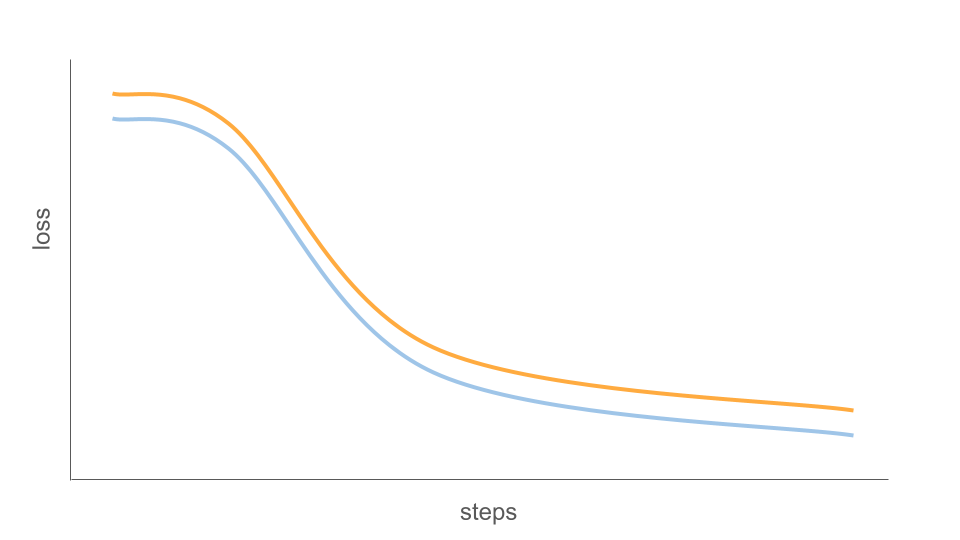

### 6.2. Metrics to Monitor


Effective monitoring involves tracking quantitative metrics, and evaluating qualitative metrics. Available metrics are:

* Training loss

* Validation loss

* Learning rate progression

* Gradient norms

Watch for these warning signs during training:

1. Validation loss increasing while training loss decreases (overfitting)

2. No significant improvement in loss values (underfitting)

3. Extremely low loss values (potential memorization)

4. Inconsistent output formatting (template learning issues)

### 6.3. The Path to Convergence


As training progresses, the loss curve should gradually stabilize. The key indicator of healthy training is a small gap between training and validation loss, suggesting the model is learning generalizable patterns rather than memorizing specific examples. The absolute loss values will vary depending on your task and dataset.



### 6.4. Monitoring Training Progress


The graph above shows a typical training progression. Notice how both training and validation loss decrease sharply at first, then gradually level off. This pattern indicates the model is learning effectively while maintaining generalization ability.



### 6.5. Warning Signs to Watch For


Several patterns in the loss curves can indicate potential issues. Below we illustrate common warning signs and solutions that we can consider.



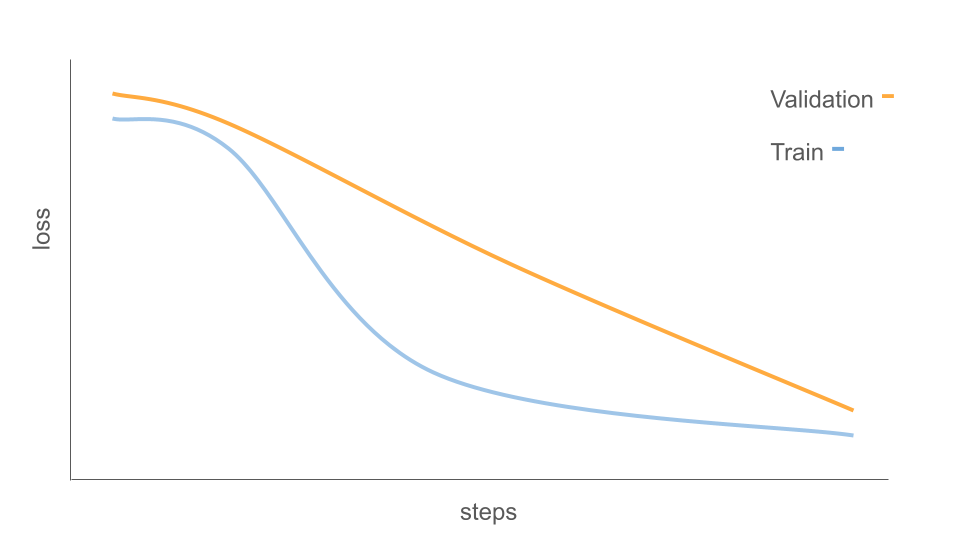

If the validation loss decreases at a significantly slower rate than training loss, your model is likely overfitting to the training data. Consider:

* Reducing the training steps

* Increasing the dataset size

* Validating dataset quality and diversity

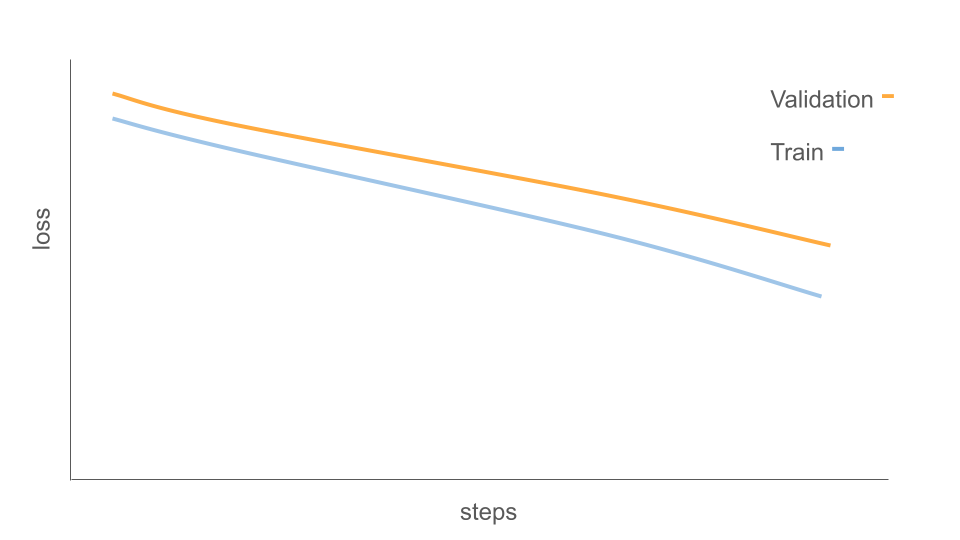

If the loss doesn’t show significant improvement, the model might be:

* Learning too slowly (try increasing the learning rate)

* Struggling with the task (check data quality and task complexity)

* Hitting architecture limitations (consider a different model)

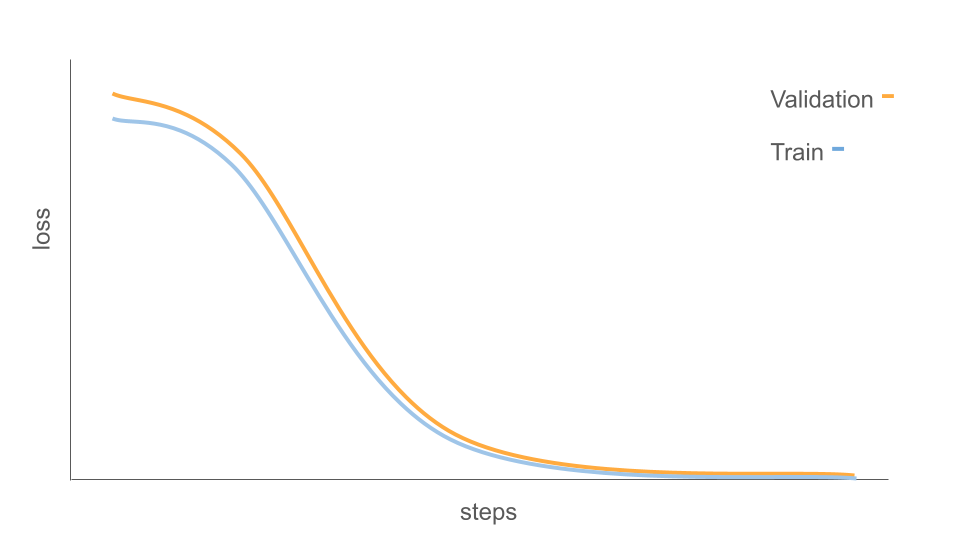

Extremely low loss values could suggest memorization rather than learning. This is particularly concerning if:

* The model performs poorly on new, similar examples

* The outputs lack diversity

* The responses are too similar to training examples

Monitor both the loss values and the model’s actual outputs during training. Sometimes the loss can look good while the model develops unwanted behaviors. Regular qualitative evaluation of the model’s responses helps catch issues that metrics alone might miss.



## 7. Evaluation after SFT


 For now, we will focus on the qualitative evaluation of the model.

After completing SFT, consider these follow-up actions:

* Evaluate the model thoroughly on held-out test data

* Validate template adherence across various inputs

* Test domain-specific knowledge retention

* Monitor real-world performance metrics

Document your training process, including:

* Dataset characteristics

* Training parameters

* Performance metrics

* Known limitations 

This documentation will be valuable for future model iterations.